**Part 1:** Exploratory Data Analysis  
**Dataset:** USA Housing  
**Goal:** Understand the data, distributions, and feature relationships before modeling.

## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('USA_Housing.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (5000, 7)

First 5 rows:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
# Data types and column info
df.info()

print('\nStatistical Summary')
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB

Statistical Summary


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,68583.11,5.98,6.99,3.98,36163.52,1232072.65
std,10657.99,0.99,1.01,1.23,9925.65,353117.63
min,17796.63,2.64,3.24,2.00,172.61,15938.66
25%,61480.56,5.32,6.30,3.14,29403.93,997577.14
50%,68804.29,5.97,7.00,4.05,36199.41,1232669.38
75%,75783.34,6.65,7.67,4.49,42861.29,1471210.20
max,107701.75,9.52,10.76,6.50,69621.71,2469065.59


In [4]:
# Check for missing values
print('Missing Values')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing Values
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Total missing: 0

Duplicate rows: 0


## 2. Target Variable Analysis — House Price

In [5]:
# Statistical summary of target
price_stats = df['Price'].describe()
print('--- Price Statistics ---')
print(f'Mean:   ${price_stats["mean"]:,.0f}')
print(f'Median: ${df["Price"].median():,.0f}')
print(f'Std:    ${price_stats["std"]:,.0f}')
print(f'Min:    ${price_stats["min"]:,.0f}')
print(f'Max:    ${price_stats["max"]:,.0f}')

--- Price Statistics ---
Mean:   $1,232,073
Median: $1,232,669
Std:    $353,118
Min:    $15,939
Max:    $2,469,066


In [6]:
# Statistical summary of target
print('Price Statistics')
print(f'Mean:   ${df["Price"].mean():,.0f}')
print(f'Median: ${df["Price"].median():,.0f}')
print(f'Std:    ${df["Price"].std():,.0f}')
print(f'Min:    ${df["Price"].min():,.0f}')
print(f'Max:    ${df["Price"].max():,.0f}')

Price Statistics
Mean:   $1,232,073
Median: $1,232,669
Std:    $353,118
Min:    $15,939
Max:    $2,469,066


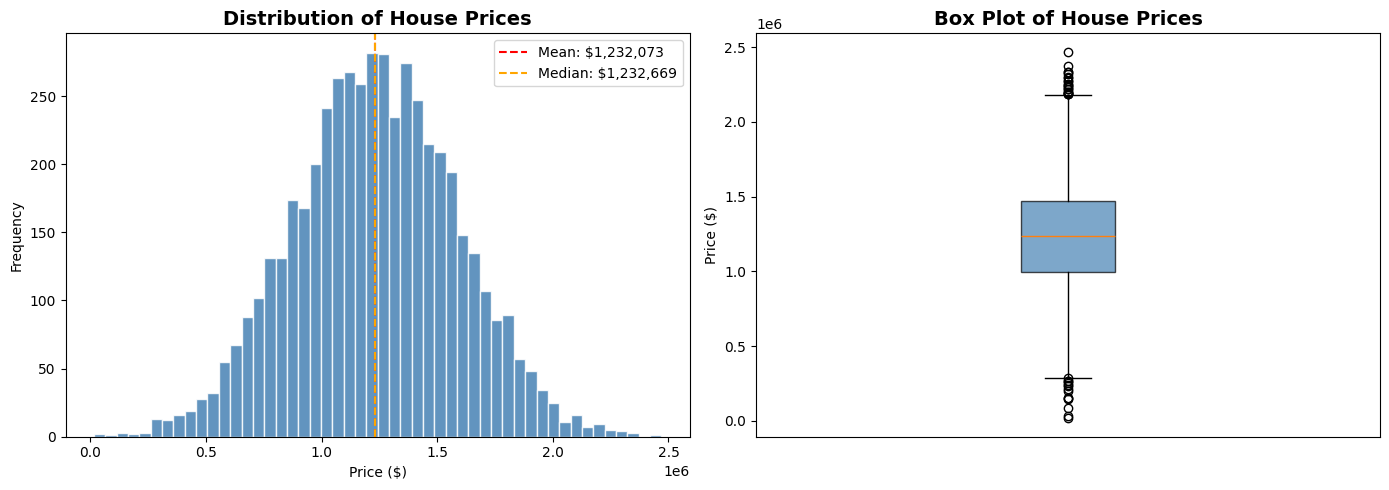

Plot saved as price_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["Price"].mean():,.0f}')
axes[0].axvline(df['Price'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${df["Price"].median():,.0f}')
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of House Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as price_distribution.png')

## 3. Feature Distributions

Numerical features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']


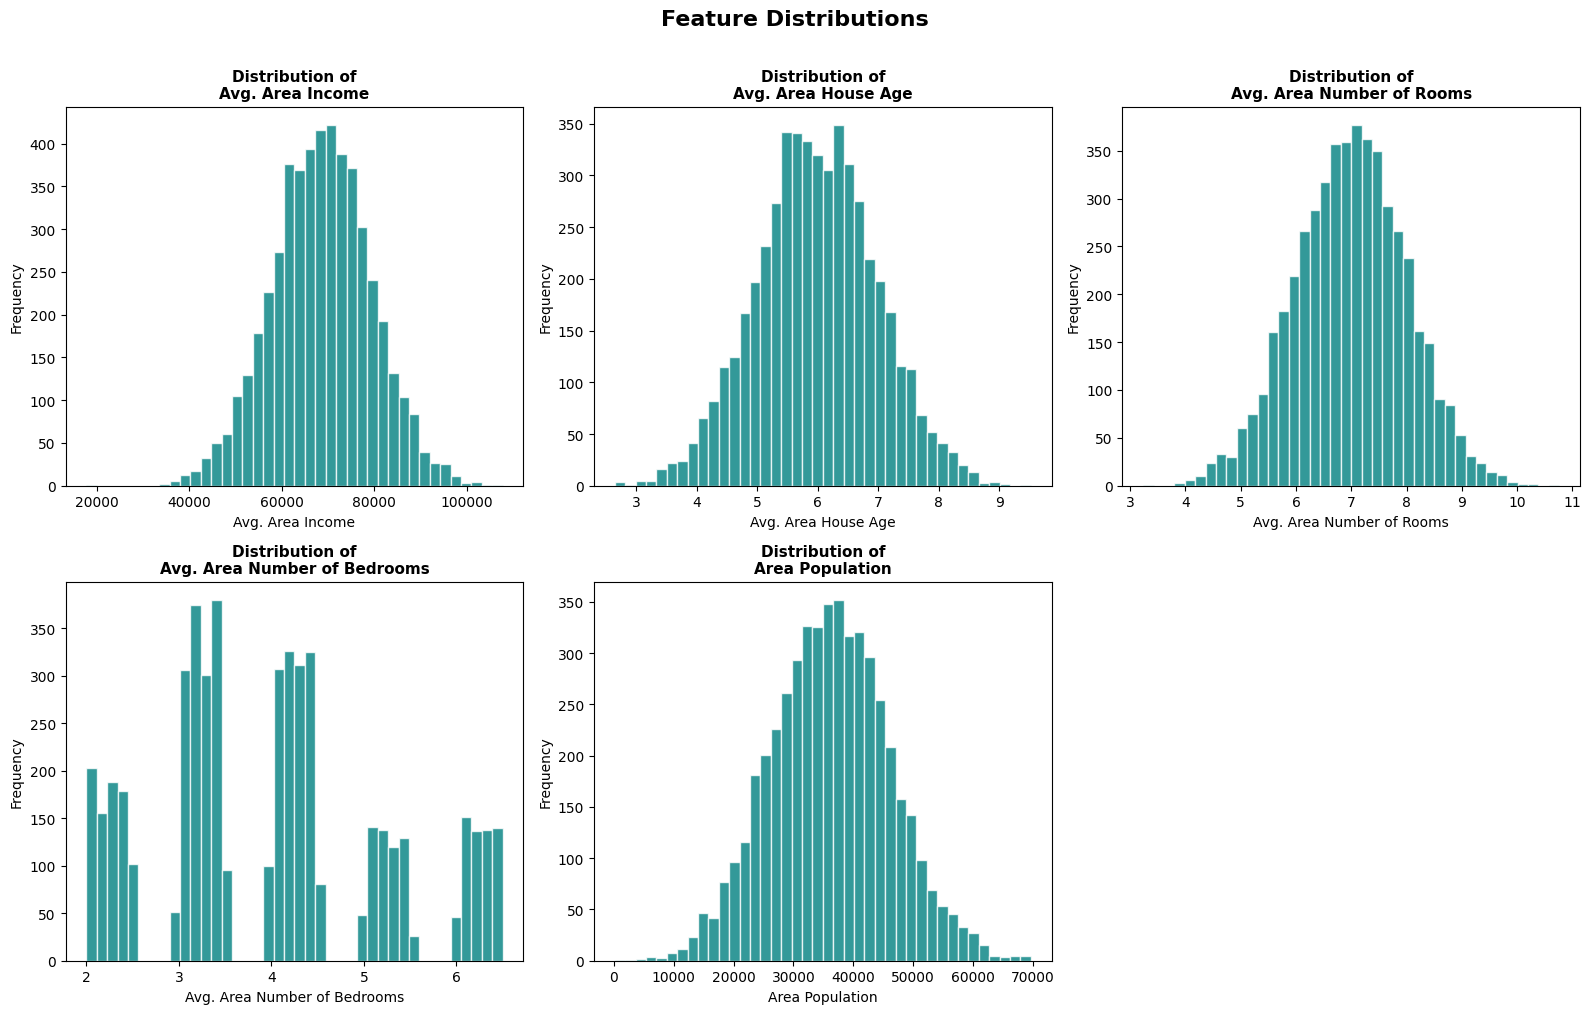

In [8]:
# only numerical features (exclude Address)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = [c for c in numerical_cols if c != 'Price']

print('Numerical features:', features)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)


plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

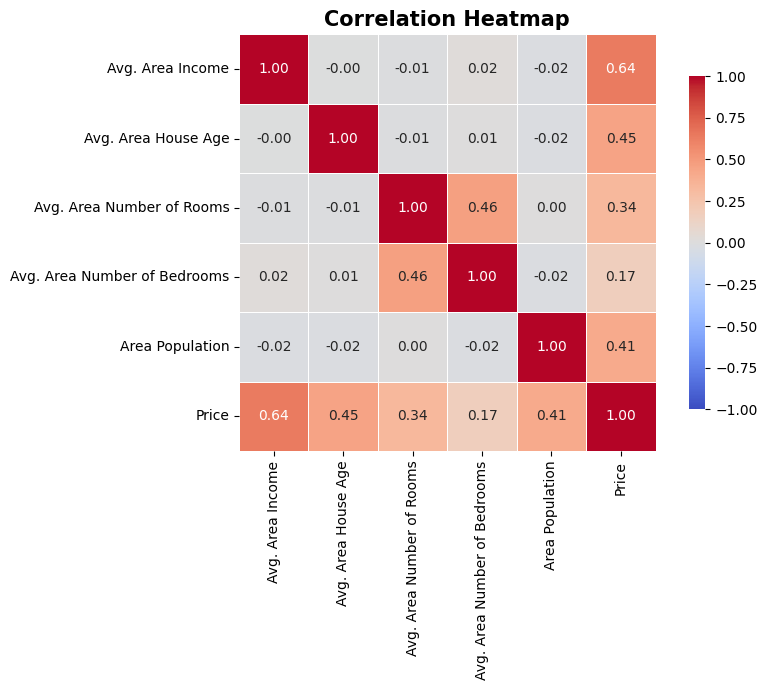

In [9]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Correlation with Price specifically
price_corr = corr_matrix['Price'].drop('Price').sort_values(ascending=False)
print('Feature Correlations with Price (sorted)')
for feat, val in price_corr.items():
    print(f'  {feat:<40} {val:.4f}')

Feature Correlations with Price (sorted)
  Avg. Area Income                         0.6397
  Avg. Area House Age                      0.4525
  Area Population                          0.4086
  Avg. Area Number of Rooms                0.3357
  Avg. Area Number of Bedrooms             0.1711


## 5. Scatter Plots — Price vs Each Feature

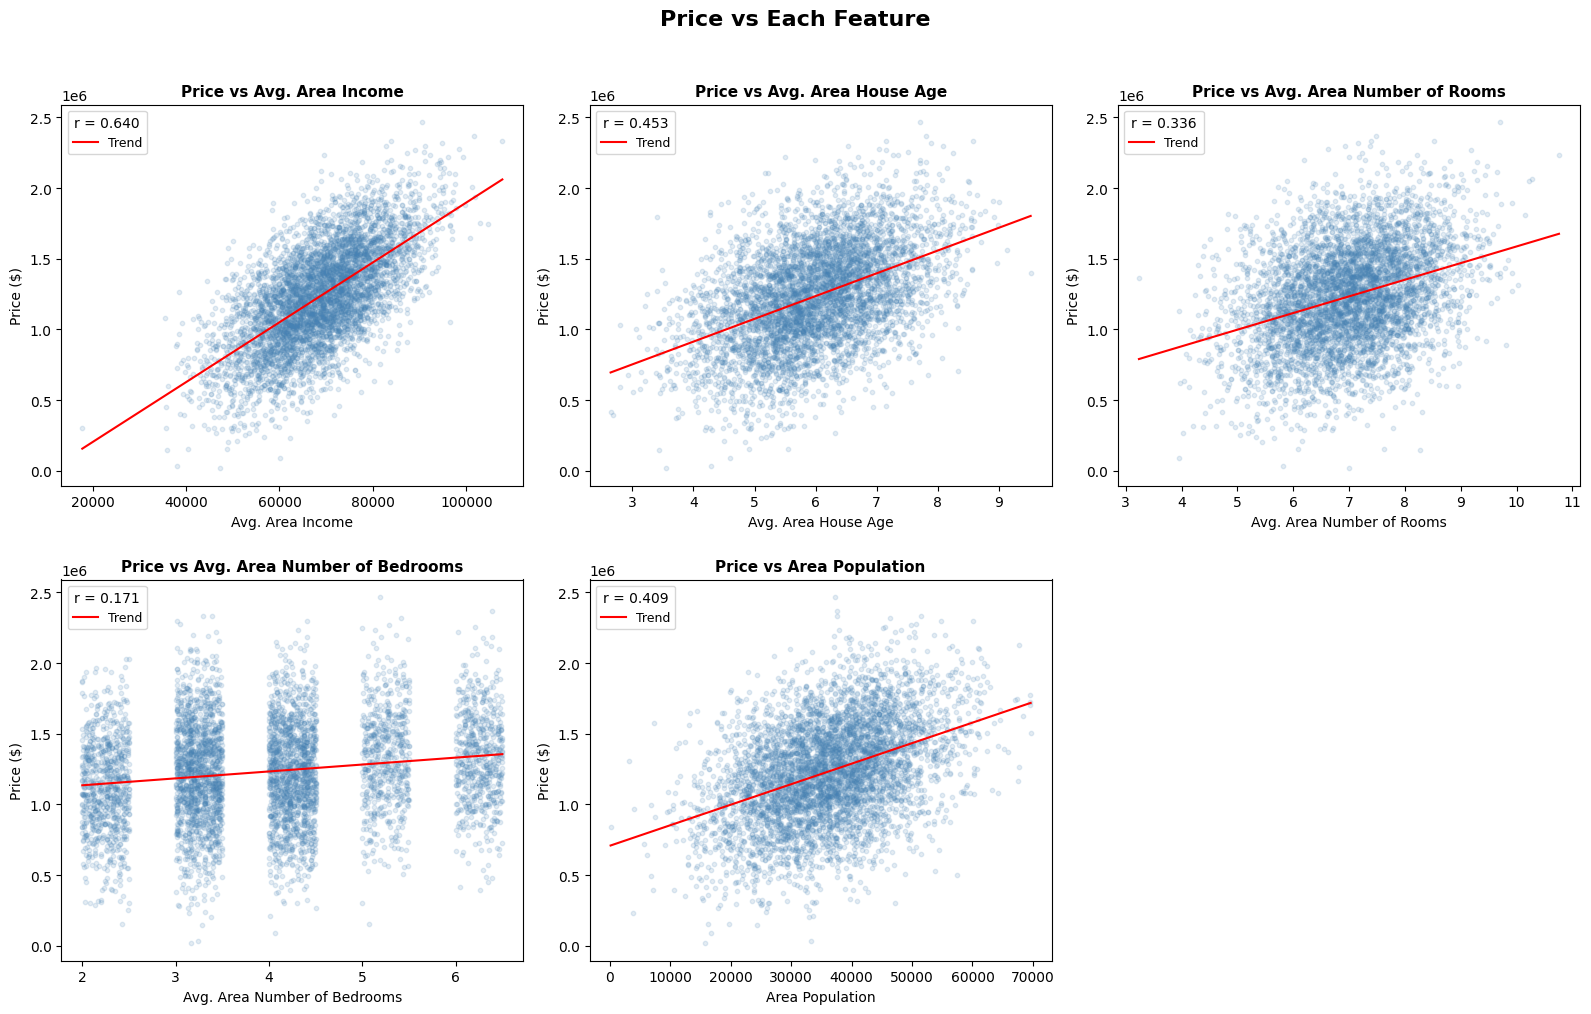

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['Price'], alpha=0.15, s=10, color='steelblue')
    # regression line
    m, b = np.polyfit(df[col], df['Price'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label='Trend')
    axes[i].set_title(f'Price vs {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price ($)')
    r = df[[col, 'Price']].corr().iloc[0, 1]
    axes[i].legend(title=f'r = {r:.3f}', fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Price vs Each Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Findings & Observations

In [12]:
print('KEY FINDINGS FROM EDA')

print('\n1. DATA QUALITY')
print(f'   - Total samples  : {df.shape[0]:,}')
print(f'   - Missing values : {df.isnull().sum().sum()}')
print(f'   - Duplicates     : {df.duplicated().sum()}')

print('\n2. TARGET VARIABLE (Price)')
print(f'   - Mean   : ${df["Price"].mean():,.0f}')
print(f'   - Median : ${df["Price"].median():,.0f}')
print(f'   - Range  : ${df["Price"].min():,.0f} — ${df["Price"].max():,.0f}')
print('   - Distribution is approximately normal (slight right skew)')

print('\n3. FEATURE IMPORTANCE (by correlation with Price)')
for feat, val in price_corr.items():
    print(f'  {feat:<40} {val:.4f}')

print('\n4. FEATURE RELATIONSHIPS')
print('   - All features show POSITIVE linear relationships with Price')
print('   - Avg. Area Income has the strongest correlation')
print('   - Relationships appear mostly linear → Linear/Polynomial models should work well')

print('\n5. FEATURE SELECTION DECISION')
print('   - "Address" is a string column → will be excluded')
print('   - All 5 numerical features will be used for modeling')
print('   - No features need to be dropped based on EDA')

print('\n6. RECOMMENDED MODELS')
print('   - Linear Regression (strong linear relationships)')
print('   - Polynomial Regression + Ridge (capture slight non-linearity)')
print('   - KNN Regression (non-parametric baseline)')

KEY FINDINGS FROM EDA

1. DATA QUALITY
   - Total samples  : 5,000
   - Missing values : 0
   - Duplicates     : 0

2. TARGET VARIABLE (Price)
   - Mean   : $1,232,073
   - Median : $1,232,669
   - Range  : $15,939 — $2,469,066
   - Distribution is approximately normal (slight right skew)

3. FEATURE IMPORTANCE (by correlation with Price)
  Avg. Area Income                         0.6397
  Avg. Area House Age                      0.4525
  Area Population                          0.4086
  Avg. Area Number of Rooms                0.3357
  Avg. Area Number of Bedrooms             0.1711

4. FEATURE RELATIONSHIPS
   - All features show POSITIVE linear relationships with Price
   - Avg. Area Income has the strongest correlation
   - Relationships appear mostly linear → Linear/Polynomial models should work well

5. FEATURE SELECTION DECISION
   - "Address" is a string column → will be excluded
   - All 5 numerical features will be used for modeling
   - No features need to be dropped based o